In [27]:
library(WGCNA)
library(clusterProfiler)
library(ggplot2)
library(biomaRt)
library(org.Hs.eg.db)

In [5]:
setwd("/home/seba/github_repos/crc_weighted_network/taiwanese_cohort/count_matrices_by_geneid")
rna_network_dir <- "../allrnas_pooled"

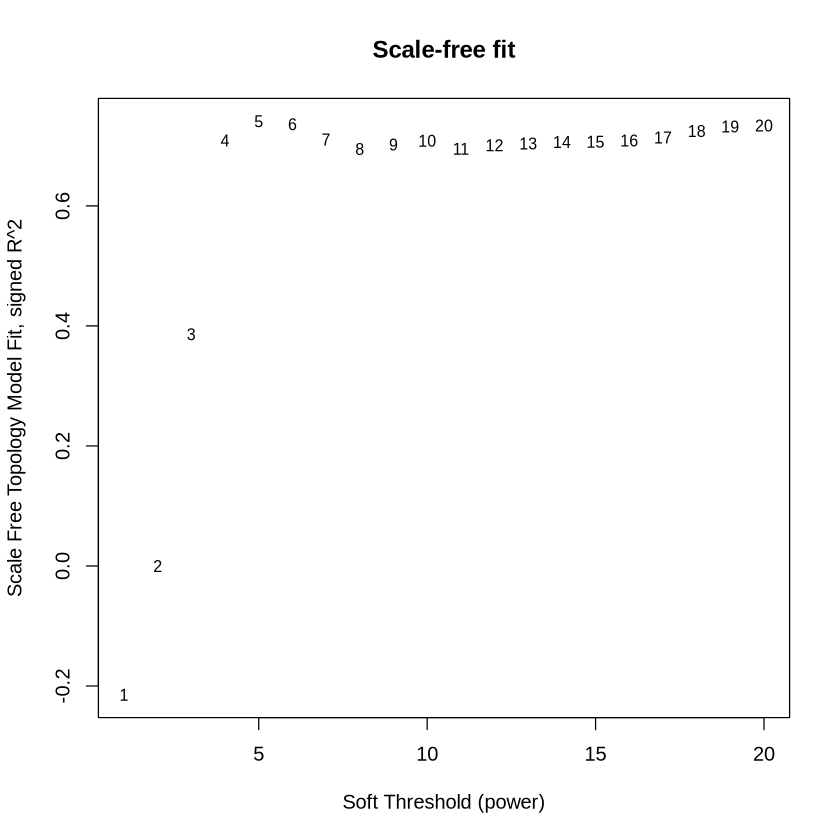

In [6]:
# Load the pre-computed WGCNA modules of RNA pooled
sft <- readRDS(paste(rna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

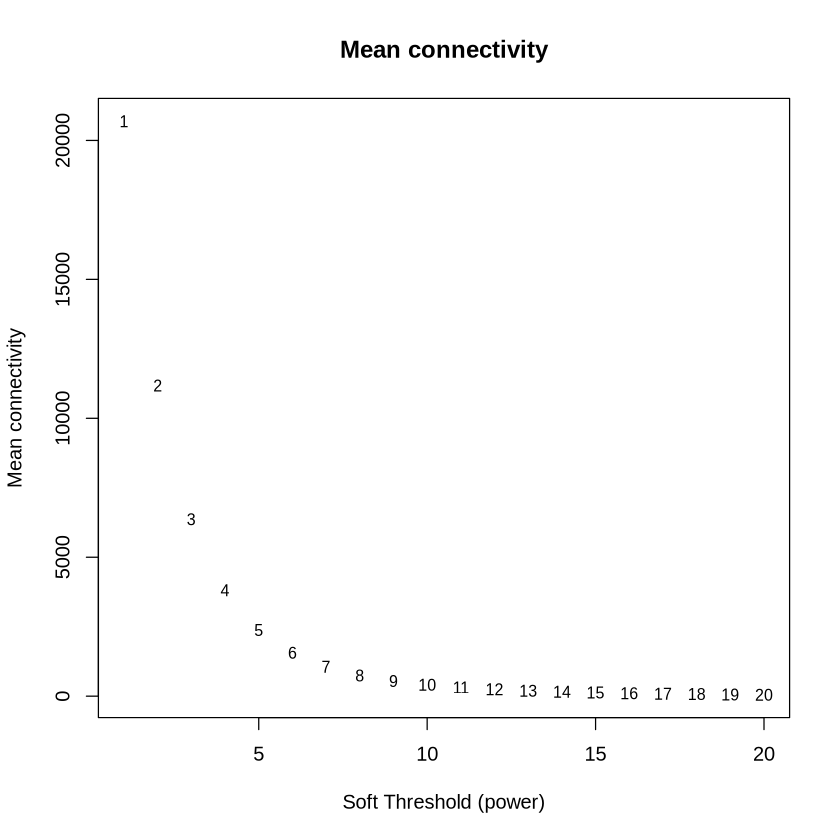

In [7]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

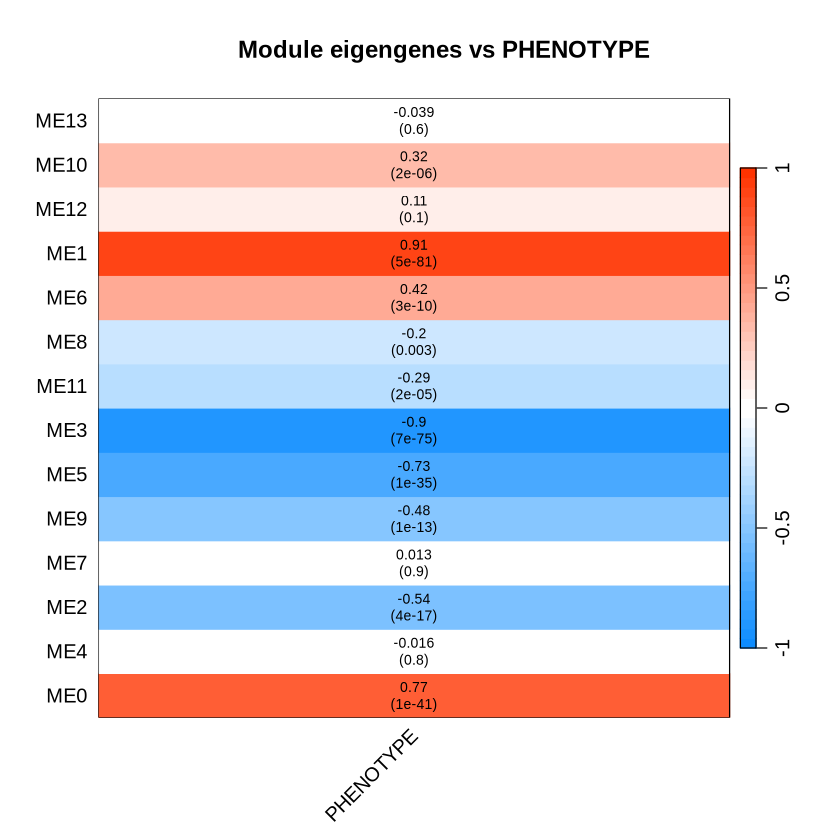

In [8]:
# Load
MEs    <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(rna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY PHENOTYPE
if (!("PHENOTYPE" %in% colnames(traits))) stop("Column 'PHENOTYPE' not found in traits.")

trait_pheno <- traits[, "PHENOTYPE", drop = FALSE]

# Convert PHENOTYPE to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno$PHENOTYPE)) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno$PHENOTYPE))
  if (length(lev) != 2) {
    stop(paste0(
      "PHENOTYPE must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev)
  trait_pheno$PHENOTYPE <- ifelse(as.character(trait_pheno$PHENOTYPE) == lev[2], 1, 0)
}

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = "PHENOTYPE",
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = "Module eigengenes vs PHENOTYPE"
)

In [10]:
net <- readRDS(paste(rna_network_dir, "/blockwise_net.rds", sep=""))
rna_net <- net
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))

In [14]:
# SALL2 ES ENSG00000165821
colnames(datExpr) <- gsub("\\..*$", "", colnames(datExpr))


In [20]:
obtener_ranking_correlacion <- function(gen_id, datExpr) {
  # 1. Validación: ¿Existe el gen en la matriz?
  if (!gen_id %in% colnames(datExpr)) {
    stop(paste("El gen", gen_id, "no se encuentra en la matriz de expresión."))
  }
  
  # 2. Calcular correlación de Pearson contra todos los demás genes
  # datExpr debe tener muestras en filas y genes en columnas
  cor_vector <- cor(datExpr[, gen_id], datExpr, use = "p")
  
  # 3. Crear el data frame con los resultados
  ranking <- data.frame(
    GeneID = colnames(cor_vector),
    r = as.vector(cor_vector),
    abs_r = abs(as.vector(cor_vector))
  )
  
  # 4. Ordenar por valor absoluto de mayor a menor
  ranking <- ranking[order(-ranking$abs_r), ]
  
  # 5. Eliminar la autocorrelación (el gen consigo mismo es siempre 1)
  ranking <- ranking[ranking$GeneID != gen_id, ]
  
  return(ranking)
}

In [22]:
ranking_sall2 <- obtener_ranking_correlacion("ENSG00000165821", datExpr)
head(ranking_sall2, 10)

,GeneID,r,abs_r
,<chr>,<dbl>,<dbl>
35541,ENSG00000291109,0.6935782,0.6935782
31898,ENSG00000257599,0.6443898,0.6443898
24189,ENSG00000250658,0.6208809,0.6208809
26778,ENSG00000289053,0.6179837,0.6179837
12871,ENSG00000166813,0.6092044,0.6092044
30657,ENSG00000298341,0.5855542,0.5855542
412,ENSG00000160097,0.5391803,0.5391803
39091,ENSG00000297617,0.5354614,0.5354614
26756,ENSG00000297140,0.5251901,0.5251901


In [25]:
anotar_ranking <- function(ranking_df) {
  # 1. Conectar con Ensembl (Humano)
  # Nota: 'useMart' puede tardar unos segundos dependiendo de la conexión
  ensembl <- useMart("ensembl", dataset = "hsapiens_gene_ensembl")
  
  # 2. Obtener la conversión
  # 'filters' debe ser el tipo de ID que tienes actualmente (ej: 'ensembl_gene_id')
  # 'attributes' son los datos que quieres obtener
  anotaciones <- getBM(
    attributes = c("ensembl_gene_id", "external_gene_name", "gene_biotype"),
    filters = "ensembl_gene_id", 
    values = ranking_df$GeneID, 
    mart = ensembl
  )
  
  # 3. Fusionar con tu ranking original
  # Usamos 'left_join' para mantener el orden de correlación
  library(dplyr)
  ranking_anotado <- ranking_df %>%
    left_join(anotaciones, by = c("GeneID" = "ensembl_gene_id")) %>%
    rename(GeneSymbol = external_gene_name, Tipo = gene_biotype)
  
  # Reordenar para que los nombres estén al principio
  ranking_anotado <- ranking_anotado[, c("GeneID", "GeneSymbol", "Tipo", "r", "abs_r")]
  
  return(ranking_anotado)
}

In [28]:
# Conversión simple
ranking_sall2$Symbol <- mapIds(org.Hs.eg.db,
                            keys = ranking_sall2$GeneID,
                            column = "SYMBOL",
                            keytype = "ENSEMBL",
                            multiVals = "first")

'select()' returned 1:many mapping between keys and columns



In [29]:
head(ranking_sall2, 10)

,GeneID,r,abs_r,Symbol
,<chr>,<dbl>,<dbl>,<chr>
35541,ENSG00000291109,0.6935782,0.6935782,CES1P1
31898,ENSG00000257599,0.6443898,0.6443898,NA
24189,ENSG00000250658,0.6208809,0.6208809,NA
26778,ENSG00000289053,0.6179837,0.6179837,NA
12871,ENSG00000166813,0.6092044,0.6092044,KIF7
30657,ENSG00000298341,0.5855542,0.5855542,NA
412,ENSG00000160097,0.5391803,0.5391803,FNDC5
39091,ENSG00000297617,0.5354614,0.5354614,NA
26756,ENSG00000297140,0.5251901,0.5251901,NA
